In [72]:
import torch
import cv2
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import scipy.io as sio
import h5py
import os


import matplotlib.pyplot as plt

In [73]:
class DnCNNGray(nn.Module):
    def __init__(self, depth=20, n_channels=64):
        super(DnCNNGray, self).__init__()
        layers = []
        layers.append(nn.Conv2d(1, n_channels, kernel_size=3, padding=1, bias=True))
        layers.append(nn.ReLU(inplace=True))
        for _ in range(depth - 2):
            layers.append(nn.Conv2d(n_channels, n_channels, kernel_size=3, padding=1, bias=False))
            layers.append(nn.BatchNorm2d(n_channels, eps=0.0001, momentum=0.95))
            layers.append(nn.ReLU(inplace=True))
        layers.append(nn.Conv2d(n_channels, 1, kernel_size=3, padding=1, bias=False))
        self.dncnn = nn.Sequential(*layers)

    def forward(self, x):
        return self.dncnn(x)


def load_dncnn_gray_from_mat(mat_path, depth=20, n_channels=64, device=None):
    device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = DnCNNGray(depth=depth, n_channels=n_channels).to(device)

    conv_layers = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
    bn_layers = [m for m in model.modules() if isinstance(m, nn.BatchNorm2d)]

    with h5py.File(mat_path, 'r') as f:
        layer_refs = f['net']['layers'][:].flatten()
        conv_i = 0
        bn_i = 0

        for ref in layer_refs:
            layer = f[ref]
            if 'weights' not in layer:
                continue

            values = [_read_mat_value(f, r) for r in layer['weights'][:].flatten()]
            values = [v for v in values if v is not None]
            if not values:
                continue

            first = values[0]

            if first.ndim == 4 and conv_i < len(conv_layers):
                conv = conv_layers[conv_i]
                conv.weight.data.copy_(torch.from_numpy(first.transpose(0, 1, 3, 2)).float())
                if len(values) > 1 and conv.bias is not None:
                    conv.bias.data.copy_(torch.from_numpy(values[1].reshape(-1)).float())
                conv_i += 1

            elif first.ndim in (1, 2) and bn_i < len(bn_layers):
                bn = bn_layers[bn_i]
                bn.weight.data.copy_(torch.from_numpy(values[0].reshape(-1)).float())
                bn.bias.data.copy_(torch.from_numpy(values[1].reshape(-1)).float())
                if len(values) > 2:
                    bn.running_mean.data.copy_(torch.from_numpy(values[2].reshape(-1)).float())
                if len(values) > 3:
                    bn.running_var.data.copy_(torch.from_numpy(values[3].reshape(-1)).float())
                bn_i += 1

    model.eval()
    return model

In [74]:


class FDnCNNColor(nn.Module):
    def __init__(self, dncnn_model, image_size=256, in_channels=3):
        """
        Architecture complète de FDnCNNColor pour la détection d'images de synthèse.
        
        Paramètres:
        - dncnn_model: L'instance du modèle DnCNN pré-entraîné.
        - image_size (int): Taille de l'image (les images doivent être croppées/redimensionnées en carré).
        - in_channels (int): 3 pour RGB, 1 pour Niveaux de gris.
        """
        super(FDnCNNColor, self).__init__()
        
        # 1. Le Filtre Prétraité (DnCNN)
        self.filter = dncnn_model
        
        # Généralement, on gèle les poids du DnCNN car il agit comme un extracteur de base
        for param in self.filter.parameters():
            param.requires_grad = False
            
        # 2. Couche d'amélioration (Conv 1x1)
        # Permet de combiner linéairement les canaux de fréquence (ex: R, G, B)
        self.enhancement = nn.Conv2d(in_channels=in_channels, 
                                     out_channels=in_channels, 
                                     kernel_size=1, 
                                     bias=True)
        
        # 3. Masque d'apprentissage (Learnable Mask)
        # Initialisé à 1, il va apprendre à masquer (mettre à 0) les fréquences inutiles
        self.mask = nn.Parameter(torch.ones(1, in_channels, image_size, image_size))
        
        # 4. Motif de référence (Reference Spectrum)
        # C'est "l'empreinte digitale" spectrale d'une image générée par IA que le modèle va apprendre
        self.reference_pattern = nn.Parameter(torch.randn(1, in_channels, image_size, image_size))

    def forward(self, x):
        # --- ÉTAPE 1 : Extraction du résidu (bruit) ---
        with torch.no_grad():
            residual = self.filter(x)
            
        # --- ÉTAPE 2 : Transformée de Fourier 2D ---
        # Calcul de la FFT 2D complexe
        fft_complex = torch.fft.fft2(residual)
        # Décalage pour centrer les basses fréquences (très important en analyse spectrale)
        fft_shifted = torch.fft.fftshift(fft_complex, dim=(-2, -1))
        
        # Calcul du spectre d'amplitude logarithmique
        # L'ajout de 1e-8 évite l'erreur mathématique log(0)
        magnitude = torch.abs(fft_shifted)
        log_magnitude = torch.log(magnitude + 1e-8)
        
        # --- ÉTAPE 3 : Amélioration et Masquage ---
        enhanced_spectrum = self.enhancement(log_magnitude)
        
        # Multiplication élément par élément (Hadamard) avec le masque
        masked_spectrum = enhanced_spectrum * self.mask
        
        # --- ÉTAPE 4 : Calcul de Similarité ---
        # On aplatit les tenseurs pour comparer globalement l'image avec le motif de référence
        batch_size = masked_spectrum.size(0)
        flat_masked = masked_spectrum.view(batch_size, -1)
        flat_reference = self.reference_pattern.view(1, -1).expand(batch_size, -1)
        
        # Similarité Cosinus entre le spectre de l'image et l'empreinte IA apprise
        similarity_score = F.cosine_similarity(flat_masked, flat_reference, dim=1)
        
        # Retourne le score (qui peut servir de logit/probabilité) 
        # et le spectre masqué (utile pour la visualisation et l'explicabilité de MaskSim)
        return similarity_score, masked_spectrum




In [75]:
def _read_mat_value(f, ref):
    if isinstance(ref, h5py.Reference):
        obj = f[ref]
    else:
        obj = f['#refs#'][str(int(ref))]

    if isinstance(obj, h5py.Dataset):
        return np.array(obj)
    if isinstance(obj, h5py.Group) and 'weights' in obj:
        nested = obj['weights'][:].flatten()
        if len(nested) == 1 and isinstance(nested[0], h5py.Reference):
            nested_obj = f[nested[0]]
            if isinstance(nested_obj, h5py.Dataset):
                return np.array(nested_obj)
    return None


def load_fdncnn_from_mat(mat_path, depth=17, n_channels=64, device=None):
    device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = FDnCNNColor(depth=depth, n_channels=n_channels).to(device)

    conv_layers = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
    bn_layers = [m for m in model.modules() if isinstance(m, nn.BatchNorm2d)]

    with h5py.File(mat_path, 'r') as f:
        layer_refs = f['net']['layers'][:].flatten()
        conv_i = 0
        bn_i = 0

        for ref in layer_refs:
            layer = f[ref]
            if 'weights' not in layer:
                continue

            values = [_read_mat_value(f, r) for r in layer['weights'][:].flatten()]
            values = [v for v in values if v is not None]
            if not values:
                continue

            first = values[0]

            if first.ndim == 4 and conv_i < len(conv_layers):
                conv = conv_layers[conv_i]
                conv.weight.data.copy_(torch.from_numpy(first.transpose(0, 1, 3, 2)).float())
                if len(values) > 1 and conv.bias is not None:
                    conv.bias.data.copy_(torch.from_numpy(values[1].reshape(-1)).float())
                conv_i += 1

            elif first.ndim in (1, 2) and bn_i < len(bn_layers):
                bn = bn_layers[bn_i]
                bn.weight.data.copy_(torch.from_numpy(values[0].reshape(-1)).float())
                bn.bias.data.copy_(torch.from_numpy(values[1].reshape(-1)).float())
                if len(values) > 2:
                    bn.running_mean.data.copy_(torch.from_numpy(values[2].reshape(-1)).float())
                if len(values) > 3:
                    bn.running_var.data.copy_(torch.from_numpy(values[3].reshape(-1)).float())
                bn_i += 1

    model.eval()
    return model


Text(0.5, 1.0, 'Image originale')

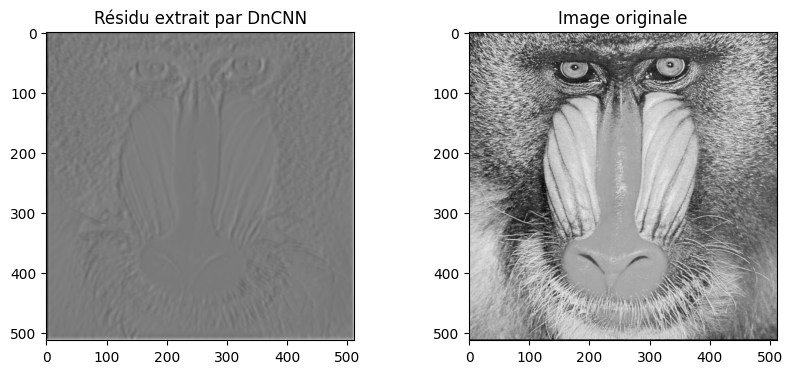

In [76]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Charger directement le modèle pré-entraîné pour noir et blanc
model = load_dncnn_gray_from_mat('DnCNN3.mat', depth=20, device=device)

# Test rapide sur une image en niveaux de gris
image_path = 'babbon.png'

def residual_extraction(image_path):
    x = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    x = torch.from_numpy(x).float().unsqueeze(0).unsqueeze(0) / 255.0
    x = x.to(device)
    with torch.no_grad():
        residual = model(x)
    return residual

# Appliquer un masque circulaire au centre du spectre pour ignorer les très basses fréquences
def filter(im, r=10):
    spec = np.fft.fftshift(np.log(np.abs(np.fft.fft2(im)) + 1e-8))
    h, w = spec.shape
    y, x = np.ogrid[:h, :w]
    center_y, center_x = h // 2, w // 2
    mask = (x - center_x) ** 2 + (y - center_y) ** 2 >= r ** 2
    spec_filtered = spec * mask
    return abs(np.fft.ifft2(np.fft.ifftshift(np.exp(spec_filtered))))

residual = residual_extraction(image_path)
residual_vis = residual[0, 0].detach().cpu()
residual_vis = residual_vis - residual_vis.min()
residual_vis = residual_vis / (residual_vis.max() + 1e-8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(residual_vis, cmap='gray')
plt.title("Résidu extrait par DnCNN")

plt.subplot(1, 2, 2)
plt.imshow(cv2.imread(image_path, cv2.IMREAD_GRAYSCALE), cmap='gray')
plt.title("Image originale")

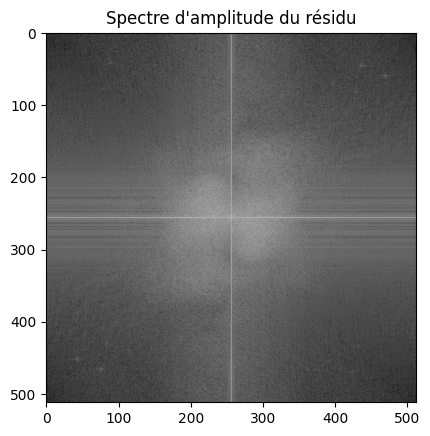

In [77]:
plt.imshow(np.fft.fftshift(np.log(np.abs(np.fft.fft2(residual_vis.cpu().numpy())) + 1e-8)), cmap='gray')
plt.title("Spectre d'amplitude du résidu")
plt.show()

Image: pashmina.jpg
La distance fréquentielle la plus probable pour le filtre bicubic est : None


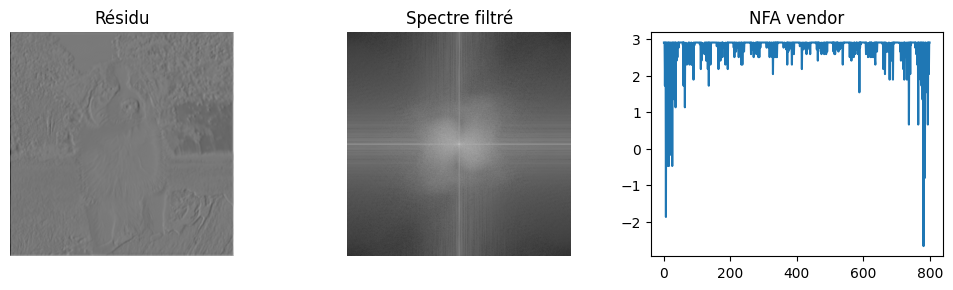

Image: pashminax1p7.jpg
La distance fréquentielle la plus probable pour le filtre bicubic est : 2.0


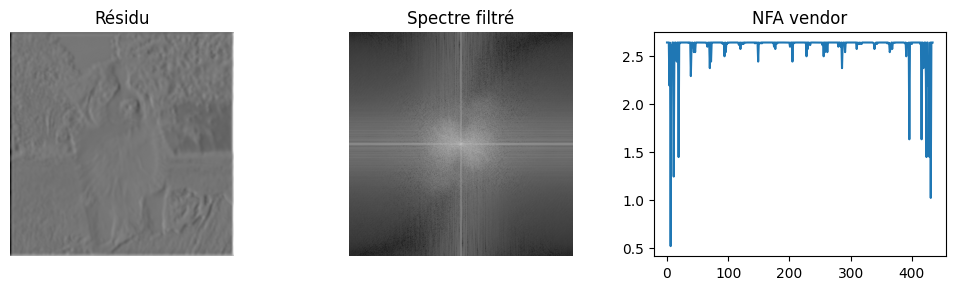

Image: pashminax4puisd4.jpg
La distance fréquentielle la plus probable pour le filtre bicubic est : 4.0


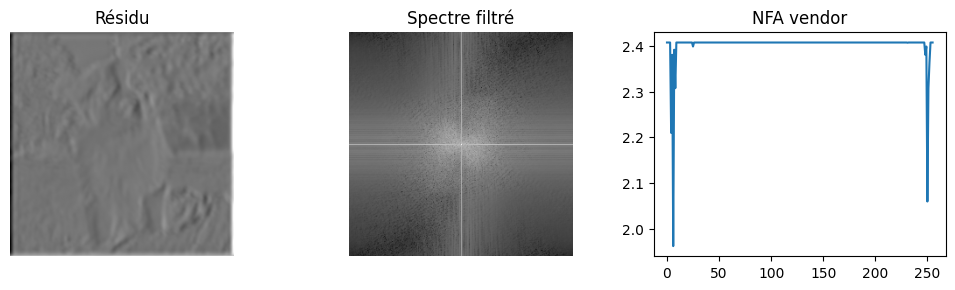

Image: pashminax4.jpg
La distance fréquentielle la plus probable pour le filtre bicubic est : None


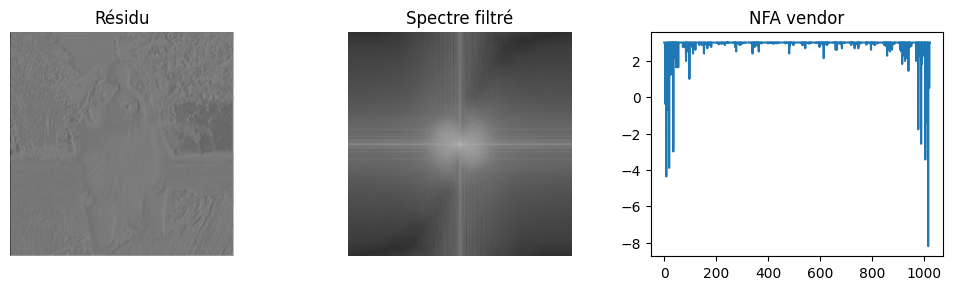

Image: pashminax8.jpg
La distance fréquentielle la plus probable pour le filtre bicubic est : None


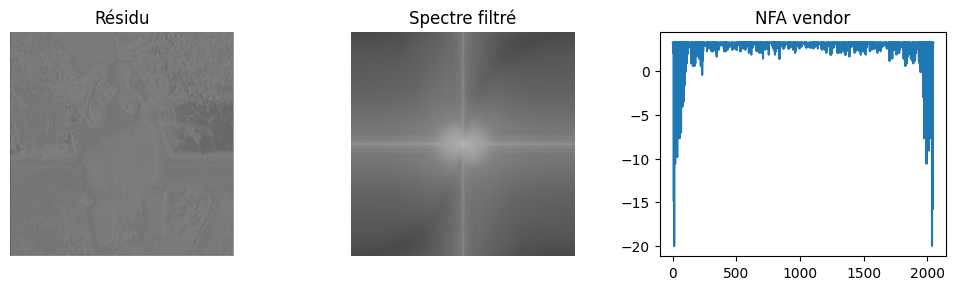

In [78]:
## TEST

import sys
import importlib

EPSILON = 1.0
CANDIDATE_SCALES = np.linspace(0.5, 8.0, 21)

NOTEBOOK_ROOT = os.path.dirname(os.path.abspath('masksim_cnn.ipynb')) if os.path.exists('masksim_cnn.ipynb') else os.getcwd()
IM206_ROOT = os.path.join(NOTEBOOK_ROOT, 'IM206')
for candidate in [NOTEBOOK_ROOT, IM206_ROOT]:
    if candidate not in sys.path:
        sys.path.insert(0, candidate)

import scale_estimation_test as setmod
setmod = importlib.reload(setmod)

# Sous-ensemble volontairement réduit pour garder la cellule exécutable
image_files = [
    "pashmina.jpg",
    #"pashminad2.jpg",
    #"pashminax0p3.jpg",
    "pashminax1p7.jpg",
    "pashminax4puisd4.jpg",
    "pashminax4.jpg",
    "pashminax8.jpg"
]
image_paths = [os.path.join(IM206_ROOT, 'IMG_InPut', name) for name in image_files]

def analyze_image(path, show_plots=True):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = filter(img, r=10)  # Appliquer le filtre pour ignorer les très basses fréquences
    if img is None:
        print(f'Impossible de charger: {path}')
        return

    residual = residual_extraction(path)[0, 0].detach().cpu()
    residual = (residual - residual.min()) / (residual.max() - residual.min() + 1e-8)

    spectrum = np.fft.fftshift(np.log(np.abs(np.fft.fft2(residual)) + 1e-8))
    spectrum_small = cv2.resize(spectrum.astype(np.float32), (256, 256), interpolation=cv2.INTER_AREA)
    # spectrum_filtered = filter(spectrum_small, radius=10)
    # residual_filtered = abs(np.fft.ifft2(np.fft.ifftshift(np.exp(spectrum_filtered))))
    nfa = setmod.vendor_nfa_from_residual(residual, is_jpeg=True, window_ratio=0.1, nb_neighbor=1)

    filtre_utilise = "bicubic"  # Choix du filtre d'interpolation pour l'estimation de l'échelle

    best_distance = setmod.find_most_probable_distance_with_interp(
        nfa_curve=nfa,
        image=img,          # Votre tenseur d'image d'entrée (x)
        residual=residual,         # Le résidu extrait par DnCNN
        interpolator_name=filtre_utilise,
        threshold=1.0              # Optionnel, seuil de sensibilité NFA
)


    # scale_nfa, info_nfa = setmod.estimate_scale_from_nfa(nfa, image_width=img.shape[1], threshold=EPSILON)
    # scale_fused, info_fused = setmod.estimate_most_probable_resampling_factor(
    #     image=img, residual=residual.numpy(), residual_spectrum=spectrum_small, NFA_valid=nfa,
    #     image_width=img.shape[1], threshold=EPSILON, candidate_scales=CANDIDATE_SCALES, dsize=(128, 128)
    # )

    print(f'Image: {os.path.basename(path)}')
    # print(f'  NFA scale: {scale_nfa}')
    # print(f'  Fused scale: {scale_fused} (interp={info_fused["best_interp"]})')
    # print(f'  NFA peaks: {info_nfa.get("detected_distances", [])[:8]}')
    print(f"La distance fréquentielle la plus probable pour le filtre {filtre_utilise} est : {best_distance}")

    if show_plots:
        plt.figure(figsize=(10, 3))
        plt.subplot(1, 3, 1)
        plt.imshow(residual, cmap='gray')
        plt.title('Résidu')
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(spectrum, cmap='gray')
        plt.title('Spectre filtré')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        v_display = np.copy(nfa)
        v_display[v_display > 1e4] = 1e4
        plt.plot(np.log10(v_display + 1e-20))
        plt.title('NFA vendor')
        plt.tight_layout()
        plt.show()

for i, path in enumerate(image_paths):
    analyze_image(path)